In [35]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

## now we will generate a dataset for classification ##

In [36]:
X,y = make_classification(n_samples = 100,n_features = 2,n_redundant = 0,n_classes = 2,n_clusters_per_class = 1,random_state=41,hypercube = False,class_sep=10)


In [37]:
print(X.shape)

(100, 2)


In [38]:
#X

In [39]:
# X ----> array of (100,2)

In [40]:
# y -----> vector of (100,)

## so we have data now

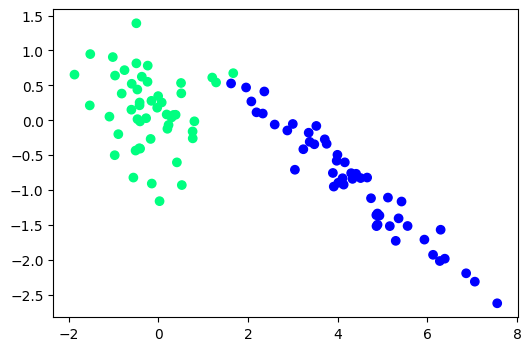

In [41]:
plt.figure(figsize = (6,4))
plt.scatter(X[:,0],X[:,1],c=y,cmap = "winter")
plt.show()

In [42]:
X_new = np.insert(X,0,1,axis = 1)
X_new ## now each row of this 2d ARRAY represents the points X0 , X1 , X2

array([[ 1.00000000e+00,  5.12201700e+00, -1.10647993e+00],
       [ 1.00000000e+00, -9.65770357e-01,  6.40315034e-01],
       [ 1.00000000e+00, -4.38224650e-03,  3.46344490e-01],
       [ 1.00000000e+00,  4.01473924e+00, -8.93524989e-01],
       [ 1.00000000e+00,  7.64292643e-01, -1.59768783e-01],
       [ 1.00000000e+00,  3.35415155e+00, -1.77932505e-01],
       [ 1.00000000e+00,  3.75461628e+00, -3.36661975e-01],
       [ 1.00000000e+00, -8.17459974e-01,  3.82475088e-01],
       [ 1.00000000e+00, -1.54056209e-01,  2.78491590e-01],
       [ 1.00000000e+00,  1.20279563e+00,  6.11959340e-01],
       [ 1.00000000e+00, -4.89995547e-01,  8.15110285e-01],
       [ 1.00000000e+00, -5.93958684e-01,  5.22671343e-01],
       [ 1.00000000e+00,  1.62248940e+00,  5.27134757e-01],
       [ 1.00000000e+00,  4.88871150e+00, -1.33421005e+00],
       [ 1.00000000e+00,  2.32988987e+00,  9.67238514e-02],
       [ 1.00000000e+00, -4.24975819e-01, -4.00399797e-01],
       [ 1.00000000e+00, -4.19130357e-01

In [43]:
# now we will start the loop
epochs = 1000
learning_rate = 0.01
asssumed_initial_line_for_perceptron_trick = np.ones(X_new.shape[1]) # so the line will be of form [1,1,1] or W0X0+W1X1+W2X2
assumed_initial_line_for_logistic_regression = np.ones(X_new[1].shape)


In [44]:
X_new[1].shape

(3,)

In [45]:
# step function for perceptron trick
def step(z):
  return 1 if z>0 else 0

# sigmoid function for logistic regression
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [46]:
print(asssumed_initial_line_for_perceptron_trick.shape)
print(X_new[34].shape)

(3,)
(3,)


In [47]:
for i in range(epochs):
  # now select a point randomly
  n = np.random.randint(0,100)
  ## so y[n] will be the actual label and y_pred will be the predicted value
  y_pred = step(asssumed_initial_line_for_perceptron_trick.dot(X_new[n]))
  asssumed_initial_line_for_perceptron_trick = asssumed_initial_line_for_perceptron_trick + learning_rate*(y[n]-y_pred)*X_new[n]



In [48]:
print(asssumed_initial_line_for_perceptron_trick)

[ 0.78       -0.57480993  0.80528708]


## now we will do the logistic regression

In [61]:
for i in range(epochs):
  # now select a point randomly
  n = np.random.randint(0,100)
  ## so y[n] will be the actual label and y_pred will be the predicted value
  y_pred = sigmoid(assumed_initial_line_for_logistic_regression.dot(X_new[n]))
  assumed_initial_line_for_logistic_regression = assumed_initial_line_for_logistic_regression + learning_rate*(y[n]-y_pred)*X_new[n]


In [62]:
print(assumed_initial_line_for_logistic_regression)


[ 1.41776048 -1.28506374  1.11827122]


In [63]:
mp = -asssumed_initial_line_for_perceptron_trick[1]/asssumed_initial_line_for_perceptron_trick[2]
cp = -asssumed_initial_line_for_perceptron_trick[0]/asssumed_initial_line_for_perceptron_trick[2]

In [64]:
ml = -assumed_initial_line_for_logistic_regression[1]/assumed_initial_line_for_logistic_regression[2]
cl = -assumed_initial_line_for_logistic_regression[0]/assumed_initial_line_for_logistic_regression[2]

In [65]:
## now we will plot all the points and the lines
xp = np.linspace(-10,10,200)
yp = mp*xp + cp

xl = np.linspace(-10,10,200)
yl = ml*xl + cl

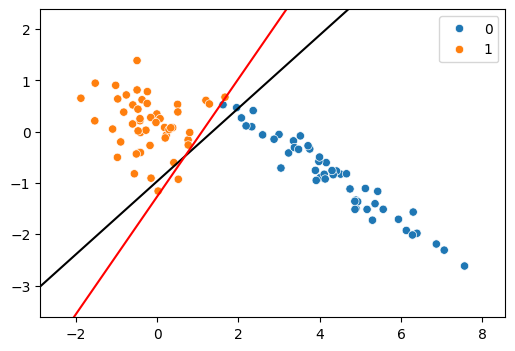

In [66]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
sns.lineplot(x = xp,y=yp,color="black")
sns.lineplot(x=xl,y=yl,color="red")
plt.xlim(X[:,0].min()-1, X[:,0].max()+1)
plt.ylim(X[:,1].min()-1, X[:,1].max()+1)

plt.show()